# 실습 내용

- 다양한 알고리즘으로 모델을 만들고 성능을 예측합니다.
- 성능이 좋을 것으로 판단된 모델의 성능을 튜닝합니다.
- 튜닝된 모델의 성능을 평가합니다.

# 1.환경 준비

- 기본 라이브러리와 대상 데이터를 가져와 이후 과정을 준비합니다.

In [1]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

- 데이터 :  airline_satisfaction_small.csv

In [3]:
path = 'data/airline_satisfaction.csv'
df = pd.read_csv(path)

df


,id,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,...,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,0
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,0
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2575,21840,Male,Loyal Customer,63,Business travel,Business,448,2,2,2,...,4,4,5,4,3,4,4,15,8.0,1
2576,42486,Female,disloyal Customer,26,Business travel,Eco,693,3,3,3,...,3,5,5,1,1,1,3,0,0.0,0
2577,49355,Male,Loyal Customer,41,Business travel,Business,3306,5,5,5,...,5,5,5,5,2,5,2,28,24.0,1
2578,46728,Female,Loyal Customer,17,Personal Travel,Eco,125,3,2,0,...,5,4,4,3,3,3,5,0,0.0,0


# 2.데이터 이해

- 분석할 데이터를 충분히 이해할 수 있도록 다양한 탐색 과정을 수행합니다.

**데이터 설명**

- id : 탑승자 고유 아이디
- gender: 성별 (Female, Male)
- customer_type: 고객 유형 (Loyal customer, disloyal customer)
- age: 탑승자 나이
- type_of_travel: 비행 목적(Personal Travel, Business Travel)
- class: 등급 (Business, Eco, Eco Plus)
- flight_distance: 비행 거리
- inflight_wifi_service: 와이파이 서비스 만족도 (0:N/A; 1-5)
- departure/arrival_time_convenient: 출발, 도착 시간 만족도 (0:N/A; 1-5)
- ease_of_online_booking: 온라인 부킹 만족도 (0:N/A; 1-5)
- gate_location: 게이트 위치 만족도 (0:N/A; 1-5)
- food_and_drink: 식사와 음료 만족도 (0:N/A; 1-5)
- online_boarding: 온라인 보딩 만족도 (0:N/A; 1-5)
- seat_comfort: 좌석 편안함 만족도 (0:N/A; 1-5)
- inflight_entertainment: 기내 엔터테인먼트 만족도 (0:N/A; 1-5)
- on-board_service: 온 보드 서비스 만족도 (0:N/A; 1-5)
- leg_room_service: 다리 공간 만족도 (0:N/A; 1-5)
- baggage_handling: 수하물 처리 만족도 (0:N/A; 1-5)
- check-in_service: 체크인 서비스 만족도 (0:N/A; 1-5)
- inflight_service: 기내 서비스 만족도 (0:N/A; 1-5)
- cleanliness: 청결 만족도 (0:N/A; 1-5)
- departure_delay_in_minutes: 출발 지연 시간(분)
- arrival_delay_in_minutes: 도착 지연 시간(분)
- satisfaction: 항공 만족도(1: Satisfaction, 0: Neutral or Dissatisfaction) - Target

In [ ]:
df.describe()


,id,age,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
count,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2574.000000,2580.000000
mean,65179.742248,39.229845,1204.824806,2.732558,3.041473,2.758527,2.973256,3.229457,3.242248,3.440310,3.329070,3.361628,3.298450,3.599225,3.318992,3.620155,3.277907,14.856202,15.285159,0.427132
std,37320.994433,15.295065,1008.852185,1.317032,1.542290,1.400792,1.271752,1.341635,1.341842,1.329681,1.334021,1.266627,1.313897,1.168210,1.256309,1.182093,1.317367,35.808534,36.301790,0.494758
min,54.000000,7.000000,67.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,32988.750000,26.000000,405.750000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000,0.000000
50%,64877.000000,40.000000,860.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000
75%,97717.000000,51.000000,1754.500000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,13.000000,14.000000,1.000000
max,129860.000000,85.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,435.000000,470.000000,1.000000


In [6]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 2580 non-null   int64  
 1   gender                             2580 non-null   str    
 2   customer_type                      2580 non-null   str    
 3   age                                2580 non-null   int64  
 4   type_of_travel                     2580 non-null   str    
 5   class                              2580 non-null   str    
 6   flight_distance                    2580 non-null   int64  
 7   inflight_wifi_service              2580 non-null   int64  
 8   departure/arrival_time_convenient  2580 non-null   int64  
 9   ease_of_online_booking             2580 non-null   int64  
 10  gate_location                      2580 non-null   int64  
 11  food_and_drink                     2580 non-null   int64  
 12  onl

In [7]:

df.isna().sum()


id                                   0
gender                               0
customer_type                        0
age                                  0
type_of_travel                       0
class                                0
flight_distance                      0
inflight_wifi_service                0
departure/arrival_time_convenient    0
ease_of_online_booking               0
gate_location                        0
food_and_drink                       0
online_boarding                      0
seat_comfort                         0
inflight_entertainment               0
on-board_service                     0
leg_room_service                     0
baggage_handling                     0
checkin_service                      0
inflight_service                     0
cleanliness                          0
departure_delay_in_minutes           0
arrival_delay_in_minutes             6
satisfaction                         0
dtype: int64

In [8]:
df.corr(numeric_only=True)

,id,age,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
id,1.000000,-0.015368,0.099408,-0.027930,-0.011158,-0.006361,-0.014071,0.045138,0.031230,0.053638,0.002769,0.029071,0.041225,0.056449,0.047594,0.067987,0.038136,0.018539,-0.005068,-0.003974
age,-0.015368,1.000000,0.078047,0.010329,0.064441,0.018626,0.009466,0.034049,0.197814,0.177556,0.052257,0.026791,0.024620,-0.073139,0.050525,-0.087237,0.059583,-0.037540,-0.034144,0.115479
flight_distance,0.099408,0.078047,1.000000,0.034791,-0.002179,0.057450,0.016260,0.067810,0.233310,0.151401,0.141815,0.111265,0.143432,0.055050,0.035266,0.053794,0.096767,-0.006341,-0.025196,0.305260
inflight_wifi_service,-0.027930,0.010329,0.034791,1.000000,0.320624,0.717404,0.356636,0.115497,0.451573,0.097381,0.200623,0.129821,0.198738,0.134191,0.023225,0.103834,0.122191,0.030221,0.023121,0.259875
departure/arrival_time_convenient,-0.011158,0.064441,-0.002179,0.320624,1.000000,0.439331,0.459399,0.014700,0.059034,0.018130,0.015226,0.064172,0.035029,0.062816,0.093228,0.072874,0.025242,0.012647,0.012714,-0.059302
ease_of_online_booking,-0.006361,0.018626,0.057450,0.717404,0.439331,1.000000,0.508303,0.034033,0.384504,0.017968,0.050631,0.027163,0.138610,0.046280,-0.006889,0.032867,0.011795,0.023704,0.017871,0.158390
gate_location,-0.014071,0.009466,0.016260,0.356636,0.459399,0.508303,1.000000,-0.016628,0.019022,-0.028575,0.009760,-0.013491,0.018238,0.026451,-0.036886,-0.007018,0.000272,0.013530,0.013358,0.021243
food_and_drink,0.045138,0.034049,0.067810,0.115497,0.014700,0.034033,-0.016628,1.000000,0.239849,0.586710,0.611201,0.088740,0.030205,0.008476,0.059618,0.034685,0.642026,-0.008821,-0.013381,0.208037
online_boarding,0.031230,0.197814,0.233310,0.451573,0.059034,0.384504,0.019022,0.239849,1.000000,0.419603,0.279503,0.143723,0.145477,0.079027,0.184845,0.080524,0.329533,-0.025518,-0.034461,0.475447
seat_comfort,0.053638,0.177556,0.151401,0.097381,0.018130,0.017968,-0.028575,0.586710,0.419603,1.000000,0.599424,0.146237,0.111184,0.047997,0.170750,0.055629,0.691808,-0.027148,-0.030866,0.338773


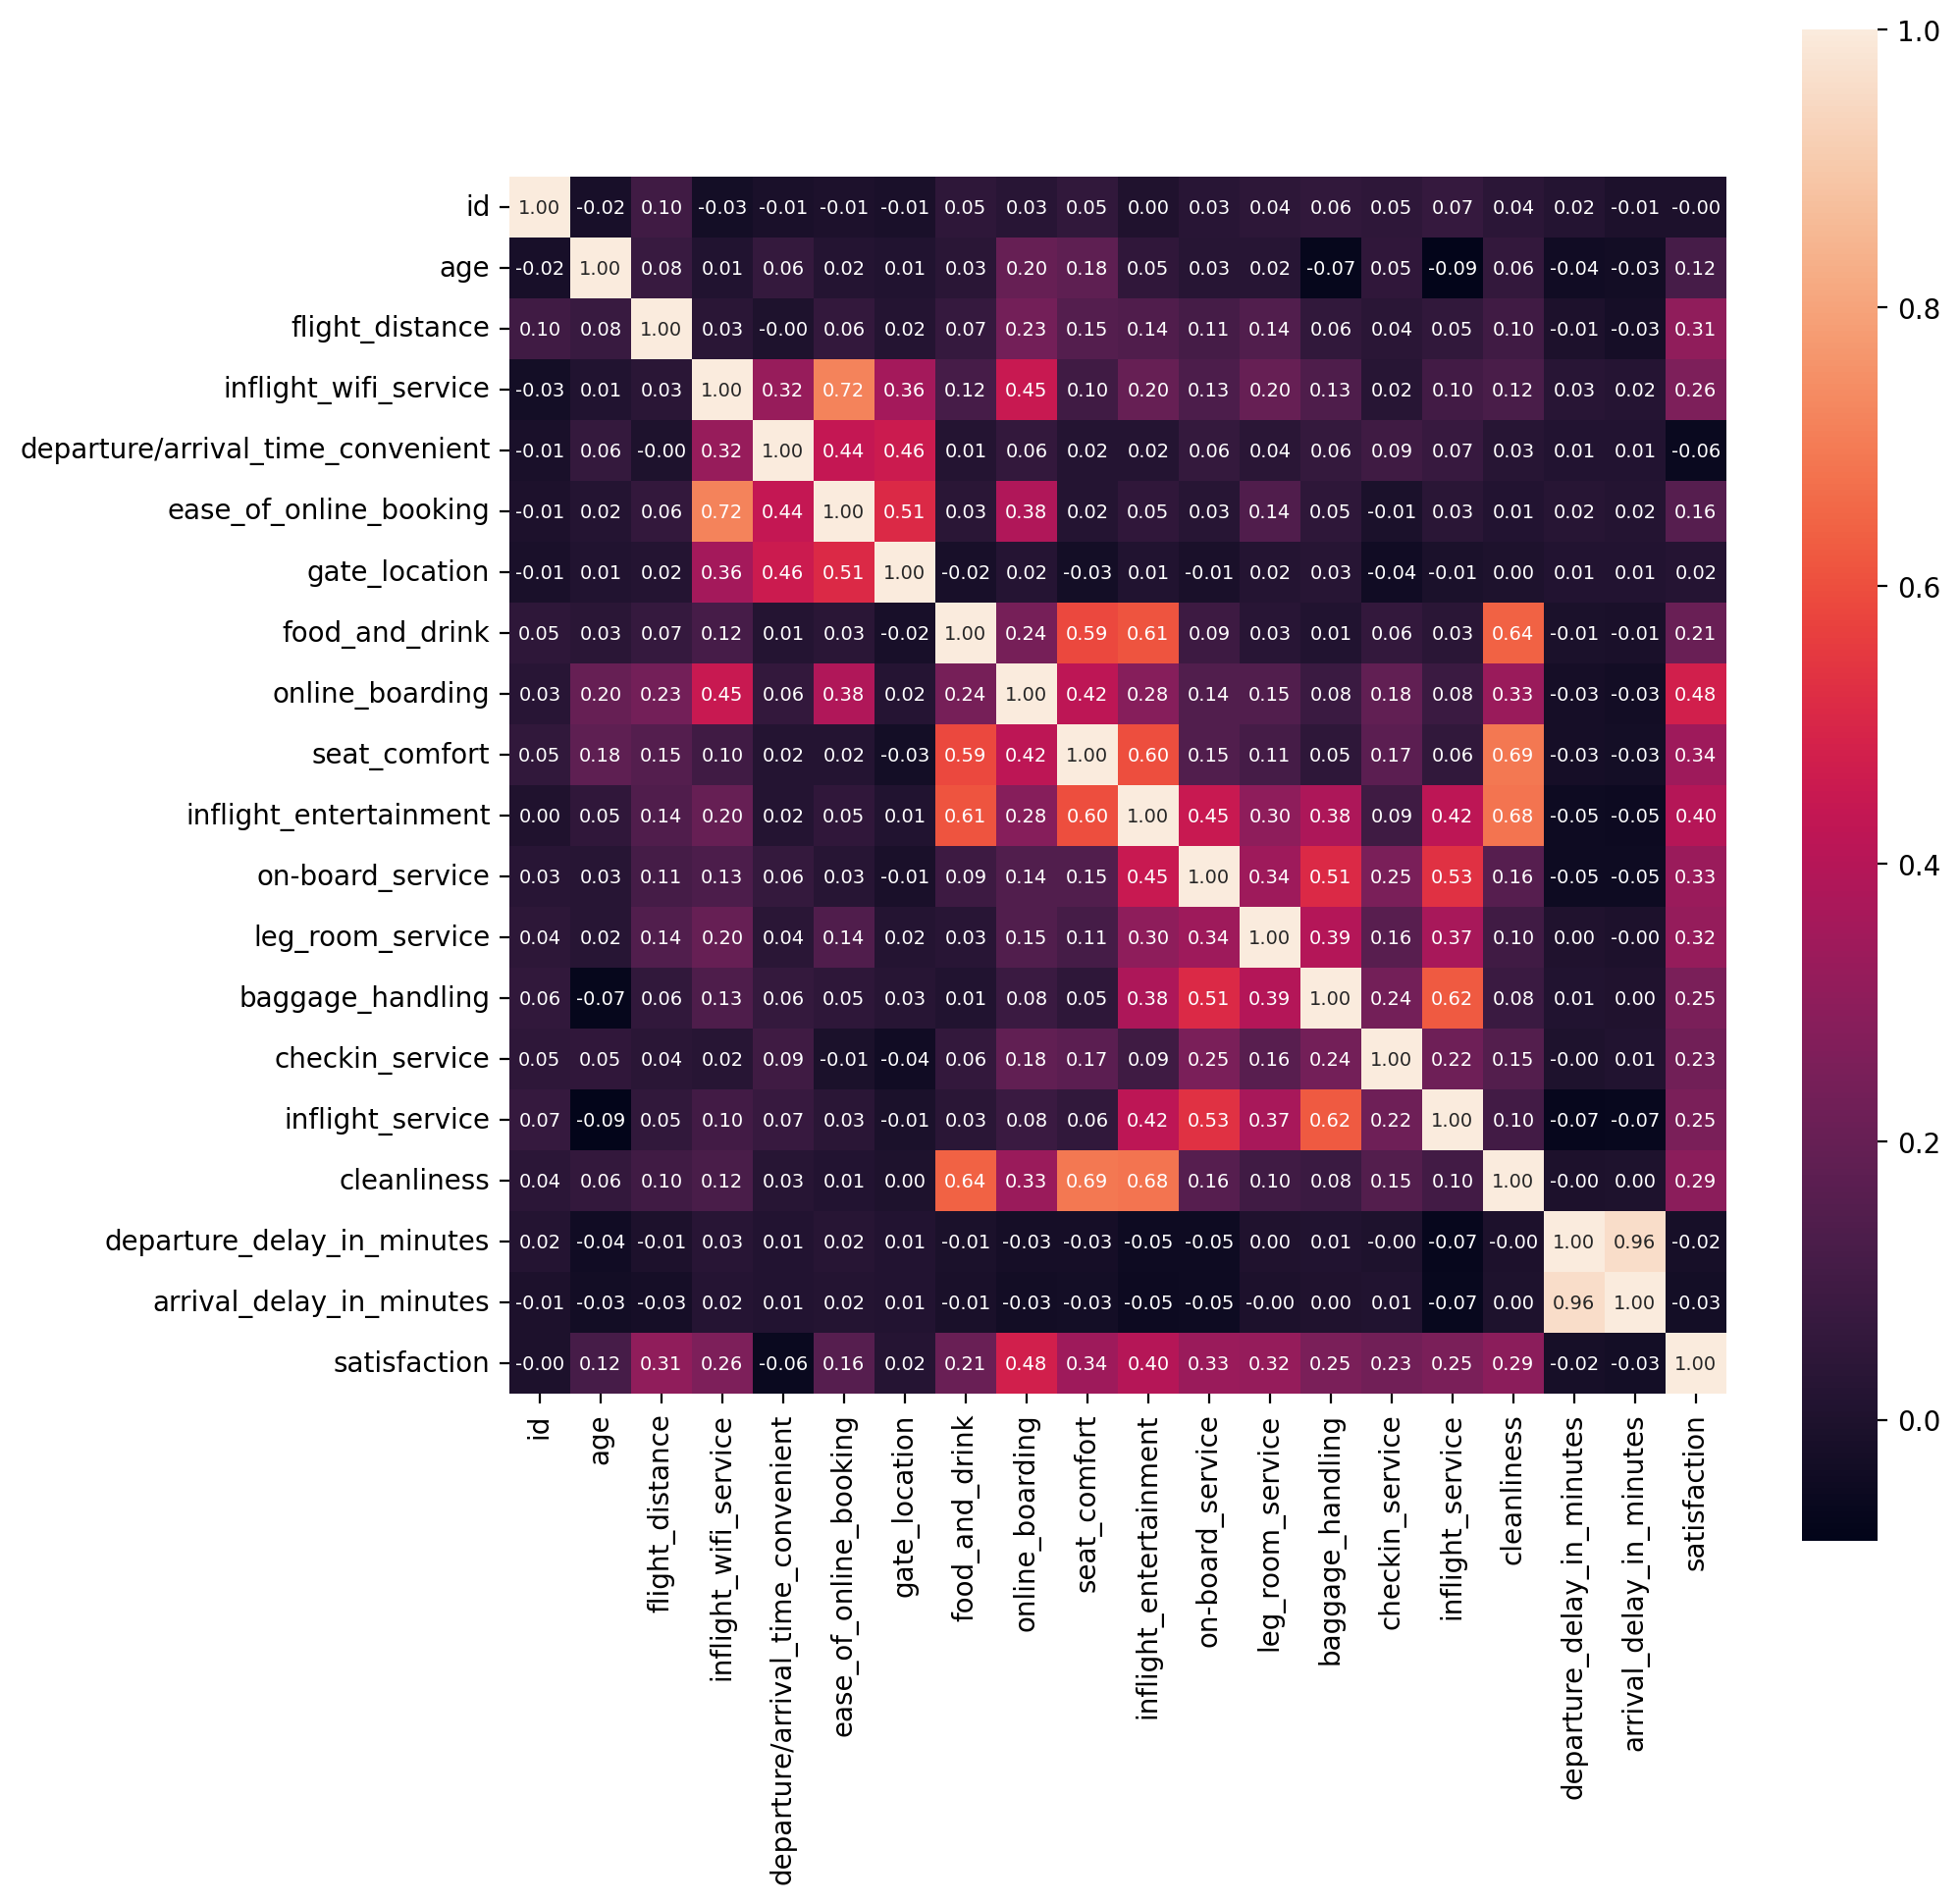

In [31]:
plt.figure(figsize=(10,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            annot_kws={'size':7},
            fmt='.2f',
            square=True
            )
plt.show()


# 3.데이터 준비

- 전처리 과정을 통해 머신러닝 알고리즘에 사용할 수 있는 형태의 데이터를 준비합니다.
- 다음과 같은 전처리를 적절한 순서에 따라 진행합니다.
    - 불필요한 변수 제거
    - 필요한 변수 추가
    - 결측치 제거
    - x, y 분리
    - 가변수화
    - 학습용, 평가용 데이터 분리
    - 스케일링(정규화) 등

In [32]:
# 제거 대상: EmployeeNumber
drop_cols = ['id']

# 변수 제거
df.drop(drop_cols, axis=1, inplace=True)

# 확인
df.head()

,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,...,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [ ]:
# target 확인
target = 'satisfaction'

# 데이터 분리
X = df.drop(target, axis=1)
y = df[target]



In [39]:
df['adim'] = df['arrival_delay_in_minutes']
df['adim'] = df['adim'].fillna(df['adim'].mean())


In [ ]:
# 가변수화 대상: gender, customer_type, type_of_travel, class
df_dummies = ['gender', 'customer_type', 'type_of_travel', 'class']

# 가변수화
X = pd.get_dummies(X, columns=df_dummies, drop_first=True)

# 확인
X.head()


In [41]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 데이터 분리
X_train,X_test, y_train, y_test = train_test_split(X, y,
                                                   train_size=0.7,
                                                   random_state=3
                                                   )



In [42]:
# 모듈 불러오기
from sklearn.preprocessing import MinMaxScaler
# 정규화
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# 4.성능 예측

- 여러 알고리즘으로 모델을 만들고 K-Fold CV로 성능을 예측합니다.
- 다음과 같은 알고리즘 중에서 일부를 대상으로 합니다.
    - Linear Regression(회귀인 경우만)
    - KNN
    - Decision Tree
    - Logistic Regression(분류인 경우만)
    - SVM
    - Random Forest
    - XGBoost
    - LigntGBM 등
- 각 모델의 예측된 성능 정보를 수집해 마지막에 비교합니다.
- 우선 이후 사용할 함수를 모두 불러옵니다.

In [43]:
# 라이브러리 불러오기
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import *
from sklearn.model_selection import cross_val_score, RandomizedSearchCV


## Logistic Regression

In [ ]:

from sklearn.linear_model import LogisticRegression

# 선언하기
model_log= LogisticRegression(max_iter=1000)

# 검증하기
cv_score = cross_val_score(model_log, X_train, y_train, cv=5, scoring='accuracy')

# 평가하기
print(cv_score)
print("평균 :", cv_score.mean())
print("표준편차 : ", cv_score.std())

# 성능정보 수집
result['Logistic Regression'] = accuracy_score(y_test, y_pred)


## KNN

## Decision Tree

## SVM

## Random Forest 

 ## XGBoost

## LigntGBM 

# 5.성능 비교

- 수집한 모델들의 성능 정보를 비교해  어떤 모델을 사용할 지 결정합니다.

# 6.성능 튜닝

- 위에서 성능이 가장 좋을 것으로 예측된 모델을 튜닝합니다.

# 7.성능 평가

- 최적 파라미터로 학습된 모델에 대해 예측과 평가를 진행합니다.